In [22]:
# STEP 1: Upload dataset ZIP file

from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4) (1).zip


In [23]:
# STEP 2: Extract dataset

import zipfile
import os

zip_file = list(uploaded.keys())[0]

extract_path = "/content/cats_dogs_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Files and folders:")
print(os.listdir(extract_path))

Dataset extracted successfully!
Files and folders:
['cats_set', 'dogs_set']


In [24]:
# STEP 3: Display folders inside dataset

for root, folders, files in os.walk(extract_path):
    print(root)

/content/cats_dogs_dataset
/content/cats_dogs_dataset/cats_set
/content/cats_dogs_dataset/dogs_set


In [25]:
# STEP 4: Find cat and dog image folders automatically

cat_folder = None
dog_folder = None

for root, folders, files in os.walk(extract_path):
    folder_name = os.path.basename(root).lower()

    if "cat" in folder_name and cat_folder is None:
        cat_folder = root

    if "dog" in folder_name and dog_folder is None:
        dog_folder = root

print("Cat folder:", cat_folder)
print("Dog folder:", dog_folder)

Cat folder: /content/cats_dogs_dataset
Dog folder: /content/cats_dogs_dataset


In [26]:
# STEP 5: Create train and validation folders

import shutil
import random

final_dataset = "/content/final_cats_dogs_dataset"

train_cat = os.path.join(final_dataset, "train", "cats")
train_dog = os.path.join(final_dataset, "train", "dogs")

val_cat = os.path.join(final_dataset, "validation", "cats")
val_dog = os.path.join(final_dataset, "validation", "dogs")

for folder in [train_cat, train_dog, val_cat, val_dog]:
    os.makedirs(folder, exist_ok=True)

print("Train and validation folders created!")

Train and validation folders created!


In [28]:
# STEP 1: Show all folders and image files

import os

for root, folders, files in os.walk(extract_path):
    image_files = [
        file for file in files
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    if image_files:
        print("IMAGE FOLDER:", root)
        print("Number of images:", len(image_files))
        print("Sample images:", image_files[:3])
        print()

IMAGE FOLDER: /content/cats_dogs_dataset/cats_set
Number of images: 500
Sample images: ['cat.4180.jpg', 'cat.4436.jpg', 'cat.4019.jpg']

IMAGE FOLDER: /content/cats_dogs_dataset/dogs_set
Number of images: 500
Sample images: ['dog.4259.jpg', 'dog.4072.jpg', 'dog.4056.jpg']



In [29]:
# STEP 2: Locate folders containing cat and dog images

def find_image_folder(keyword):
    possible_folders = []

    for root, folders, files in os.walk(extract_path):
        image_count = sum(
            file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
            for file in files
        )

        folder_name = os.path.basename(root).lower()

        if keyword in folder_name and image_count > 0:
            possible_folders.append((root, image_count))

    return possible_folders


cat_folders = find_image_folder("cat")
dog_folders = find_image_folder("dog")

print("Cat folders found:")
print(cat_folders)

print("\nDog folders found:")
print(dog_folders)

Cat folders found:
[('/content/cats_dogs_dataset/cats_set', 500)]

Dog folders found:
[('/content/cats_dogs_dataset/dogs_set', 500)]


In [30]:
# STEP 3: Select the folders containing actual images

cat_folder = cat_folders[0][0]
dog_folder = dog_folders[0][0]

print("Selected cat folder:", cat_folder)
print("Selected dog folder:", dog_folder)

print("Number of cat images:", len(os.listdir(cat_folder)))
print("Number of dog images:", len(os.listdir(dog_folder)))

Selected cat folder: /content/cats_dogs_dataset/cats_set
Selected dog folder: /content/cats_dogs_dataset/dogs_set
Number of cat images: 500
Number of dog images: 500


In [31]:
# STEP 4: Remove previously created empty folders

import shutil

final_dataset = "/content/final_cats_dogs_dataset"

if os.path.exists(final_dataset):
    shutil.rmtree(final_dataset)

print("Old empty folders removed!")

Old empty folders removed!


In [32]:
# STEP 5: Create fresh train and validation folders

train_cat = os.path.join(final_dataset, "train", "cats")
train_dog = os.path.join(final_dataset, "train", "dogs")

val_cat = os.path.join(final_dataset, "validation", "cats")
val_dog = os.path.join(final_dataset, "validation", "dogs")

for folder in [train_cat, train_dog, val_cat, val_dog]:
    os.makedirs(folder, exist_ok=True)

print("Fresh folders created!")

Fresh folders created!


In [33]:
# STEP 6: Split images into training and validation folders

import random
import shutil

def get_image_files(folder):
    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp")

    return [
        os.path.join(folder, file)
        for file in os.listdir(folder)
        if file.lower().endswith(valid_extensions)
    ]


cat_images = get_image_files(cat_folder)
dog_images = get_image_files(dog_folder)

random.seed(42)

random.shuffle(cat_images)
random.shuffle(dog_images)

cat_split = int(len(cat_images) * 0.8)
dog_split = int(len(dog_images) * 0.8)

cat_train_images = cat_images[:cat_split]
cat_validation_images = cat_images[cat_split:]

dog_train_images = dog_images[:dog_split]
dog_validation_images = dog_images[dog_split:]


def copy_images(image_paths, destination):
    for image_path in image_paths:
        shutil.copy2(image_path, destination)


copy_images(cat_train_images, train_cat)
copy_images(cat_validation_images, val_cat)

copy_images(dog_train_images, train_dog)
copy_images(dog_validation_images, val_dog)

print("Images split successfully!")
print("Training cats:", len(os.listdir(train_cat)))
print("Training dogs:", len(os.listdir(train_dog)))
print("Validation cats:", len(os.listdir(val_cat)))
print("Validation dogs:", len(os.listdir(val_dog)))

Images split successfully!
Training cats: 400
Training dogs: 400
Validation cats: 100
Validation dogs: 100


In [34]:
# STEP 7: Import libraries

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [35]:
# STEP 8: Select CPU or GPU

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [36]:
# STEP 9: Image preprocessing and augmentation

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

validation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations created!")

Image transformations created!


In [37]:
# STEP 10: Load training and validation datasets

train_dataset = datasets.ImageFolder(
    "/content/final_cats_dogs_dataset/train",
    transform=train_transform
)

validation_dataset = datasets.ImageFolder(
    "/content/final_cats_dogs_dataset/validation",
    transform=validation_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))

Classes: ['cats', 'dogs']
Training images: 800
Validation images: 200


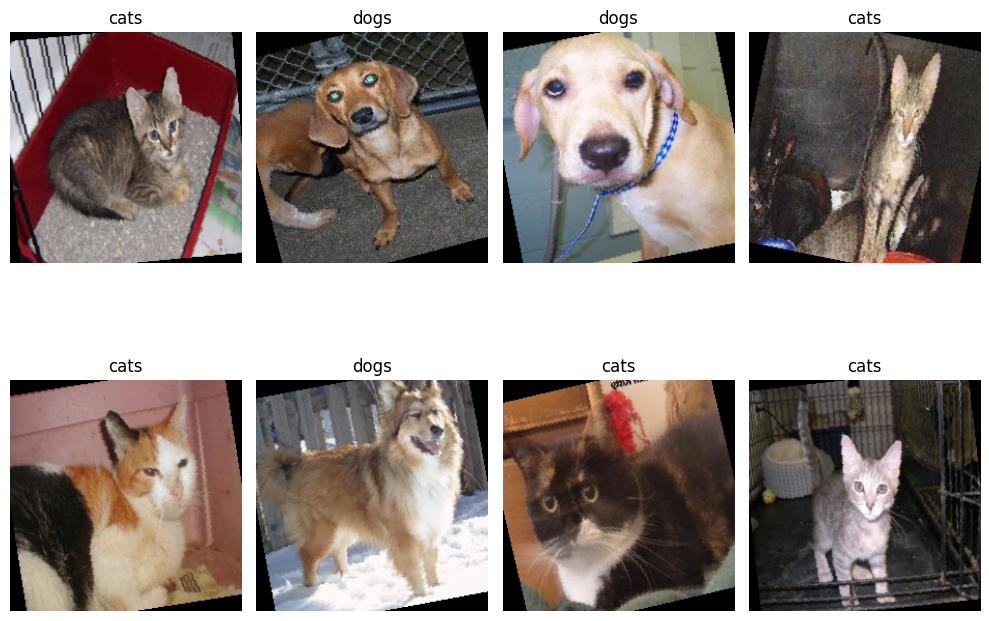

In [38]:
# STEP 11: Display sample images

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 8))

for i in range(min(8, len(images))):
    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization
    image = image * np.array([0.229, 0.224, 0.225])
    image = image + np.array([0.485, 0.456, 0.406])
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
# STEP 12: Load pretrained ResNet18

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

print("Pretrained ResNet18 loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


Pretrained ResNet18 loaded successfully!


In [40]:
# STEP 13: Freeze ResNet18 pretrained layers

for parameter in model.parameters():
    parameter.requires_grad = False

print("Pretrained layers frozen!")

Pretrained layers frozen!


In [41]:
# STEP 14: Replace final layer for two classes

number_of_features = model.fc.in_features

model.fc = nn.Linear(
    number_of_features,
    2
)

model = model.to(device)

print("Final layer replaced!")
print(model.fc)

Final layer replaced!
Linear(in_features=512, out_features=2, bias=True)


In [42]:
# STEP 15: Define loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss and optimizer ready!")

Loss and optimizer ready!


In [43]:
# STEP 16: Train ResNet18

epochs = 3

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/3] Loss: 0.3237 Accuracy: 88.12%
Epoch [2/3] Loss: 0.1946 Accuracy: 92.75%
Epoch [3/3] Loss: 0.1692 Accuracy: 93.12%


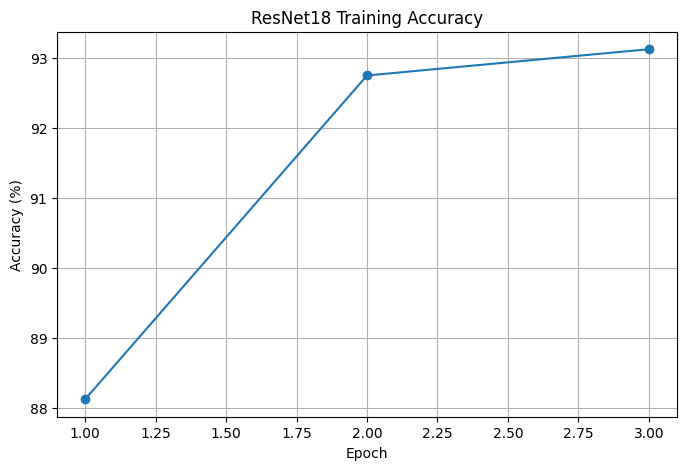

In [44]:
# STEP 17: Plot training accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_accuracies,
    marker="o"
)

plt.title("ResNet18 Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

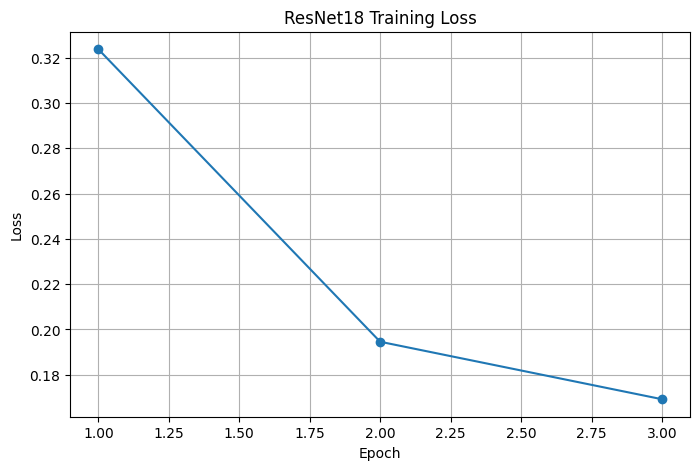

In [45]:
# STEP 18: Plot training loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o"
)

plt.title("ResNet18 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [46]:
# STEP 19: Evaluate validation accuracy

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in validation_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

validation_accuracy = 100 * correct / total

print(
    f"Validation Accuracy: {validation_accuracy:.2f}%"
)

Validation Accuracy: 94.50%


In [47]:
# STEP 20: Predict one validation image

from PIL import Image

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")

    image_tensor = validation_transform(image)
    image_tensor = image_tensor.unsqueeze(0)
    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)

    predicted_class = train_dataset.classes[predicted.item()]

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title("Prediction: " + predicted_class)
    plt.axis("off")
    plt.show()

    print("Predicted class:", predicted_class)

Testing image: /content/final_cats_dogs_dataset/validation/cats/cat.4007.jpg


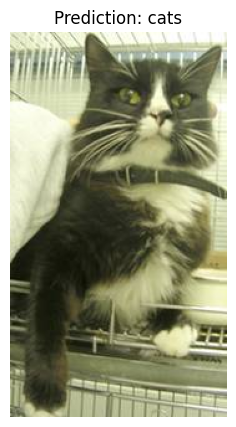

Predicted class: cats


In [48]:
# STEP 21: Test prediction

sample_image = validation_dataset.samples[0][0]

print("Testing image:", sample_image)

predict_image(sample_image)

In [49]:
# STEP 22: Save trained ResNet18 model

torch.save(
    model.state_dict(),
    "/content/resnet18_cats_dogs.pth"
)

print("Model saved successfully!")

Model saved successfully!
